# PSO-AFWCIL Full Experiment Notebook
Notebook này triển khai toàn bộ 4 kịch bản thực nghiệm theo file `kich_ban_thu_nghiem.txt`.

**Cấu trúc:**
- Cell 2: Imports & Setup
- Cell 4: Base Classifiers
- Cell 6: Utility Functions (Tomek, Gmean, CSV helpers)
- Cell 8: Fuzzy Weight (CalFW)
- Cell 10: AFW-CIL Core (`data_tomelinks_final` + `data_tomelinks_parametric`)
- Cell 12: LFB Loops (`lfb_fixed` + `lfb_pso`)
- Cell 14: PSO Optimizer Class
- Cell 16: GridSearch Baseline
- Cell 18: Universal Data Loader
- Cell 20: **Kịch bản 1** - Đánh giá PSO vs GridSearch
- Cell 22: **Kịch bản 2** - Hybrid Pipeline Evaluation (6 mô hình)
- Cell 24: **Kịch bản 3** - Stress Test (Co-Author nhiều IR)
- Cell 26: **Kịch bản 4** - Ablation Study
- Cell 28: Result Aggregation & Visualization

## Cell 1: Imports & Environment Setup

In [1]:
import sys, os, math, csv, time, tracemalloc
import numpy as np
import pandas as pd
from datetime import datetime

# ── sys.path ──────────────────────────────────────────────────────────────
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(f"sys.path: {parent_dir}")

# ── sklearn ───────────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (confusion_matrix, roc_auc_score, f1_score,
                              accuracy_score, classification_report)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split as tts

# ── imbalanced-learn ──────────────────────────────────────────────────────
from imblearn.over_sampling import BorderlineSMOTE

# ── project modules ───────────────────────────────────────────────────────
from wsvm.application import Wsvm
from svm.application import Svm
from fuzzy.weight import fuzzy

# ── output directories ────────────────────────────────────────────────────
OUTPUT_DIR     = './Experiment'
TEXT_SCRIPT    = './text_script'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TEXT_SCRIPT, exist_ok=True)

# ── matplotlib ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

print("✔ Imports OK")


sys.path: /home/quangvd/project/FAIR-2022
✔ Imports OK


## Cell 2: Base Classifier Wrappers

In [2]:
def svm_lib(X_train, y_train, X_test):
    svc = SVC(probability=True, kernel='linear')
    return svc.fit(X_train, y_train).predict(X_test)

def wsvm(C, X_train, y_train, X_test, distribution_weight=None):
    model = Wsvm(C, distribution_weight)
    model.fit(X_train, y_train)
    return model.predict(X_test)

def svm(C, X_train, y_train, X_test):
    model = Svm(C)
    model.fit(X_train, y_train)
    return model.predict(X_test)


## Cell 3: Utility Functions – Tomek Links, G-mean, Metrics, CSV Helpers

In [3]:
def is_tomek(X, y, class_type):
    """Return links (bool array), X_dangxet (list of neg TL indices), X_tl (list of pos TL indices)."""
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)
    _, neighbor_indices = nn.kneighbors(X)
    nn_index = neighbor_indices[:, 1]
    links = np.zeros(len(y), dtype=bool)
    class_excluded = [c for c in np.unique(y) if c not in class_type]
    X_dangxet, X_tl = [], []
    for idx, tgt in enumerate(y):
        if tgt in class_excluded:
            continue
        if y[nn_index[idx]] != tgt:
            if nn_index[nn_index[idx]] == idx:
                X_tl.append(idx)
                X_dangxet.append(nn_index[idx])
                links[idx] = True
    return links, X_dangxet, X_tl


def Gmean(y_test, y_pred):
    """Compute SP, SE, G-mean safely – always forces 2x2 CM with labels [-1, 1]."""
    cm = confusion_matrix(y_test, y_pred, labels=[-1.0, 1.0])
    TN, FP, FN, TP = cm.ravel()
    SE = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    SP = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    gm = math.sqrt(SE * SP)
    return SP, SE, gm


def metr_text(f, X_train, y_test, pred, sp, se, gm):
    """Write detailed metrics to an open file handle."""
    f.write(f"\nTrain={len(X_train)} | Test={len(y_test)}\n")
    f.write(classification_report(y_test, pred, zero_division=0))
    f.write(f"SP={sp:.4f} | SE={se:.4f} | Gmean={gm:.4f} | "
            f"F1={f1_score(y_test, pred, zero_division=0):.4f} | "
            f"Acc={accuracy_score(y_test, pred):.4f} | "
            f"AUC={roc_auc_score(y_test, pred):.4f}\n")


# CSV schema: ['Times','Fold','T','Name Method','Name Function',
#              'SP','SE','Gmean','F1 Score','Accuracy','AUC','Confusion Matrix']
CSV_HEADER = ['Times', 'Fold', 'T', 'Name Method', 'Name Function',
              'SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC', 'Confusion Matrix']

def append_csv_row(filepath, row):
    """Append a single data row (list) to a CSV file (auto-header if new)."""
    write_header = not os.path.exists(filepath)
    with open(filepath, 'a', encoding='UTF8', newline='') as fcsv:
        w = csv.writer(fcsv)
        if write_header:
            w.writerow(CSV_HEADER)
        w.writerow(row)


def make_row(times, fold, t_iter, namemethod, namefunction,
             sp, se, gm, f1, acc, auc, cm_str):
    """Assemble one CSV row from pre-computed scalar metrics."""
    return [times, fold, t_iter, namemethod, namefunction,
            round(float(sp), 4), round(float(se), 4), round(float(gm), 4),
            round(float(f1), 4), round(float(acc), 4), round(float(auc), 4),
            cm_str]


print("✔ Utility functions OK")


✔ Utility functions OK


## Cell 4: Fuzzy Weight Initialization (CalFW)

In [4]:
def compute_weight(X, y, name_method="distance_center_own_opposite_tam",
                   name_function="func_own_opp_new",
                   beta=None, C=None, gamma=None, u=None, sigma=None):
    method   = fuzzy.method()
    function = fuzzy.function()
    pos_index = np.where(y == 1)[0]
    neg_index = np.where(y == -1)[0]
    try:
        if   name_method == "own_class_center":
            d = method.own_class_center(X, y)
        elif name_method == "estimated_hyper_lin":
            d = method.estimated_hyper_lin(X, y)
        elif name_method == "own_class_center_opposite":
            d = method.own_class_center_opposite(X, y)
        elif name_method == "actual_hyper_lin":
            d = method.actual_hyper_lin(X, y, C=C, gamma=gamma)
        elif name_method == "own_class_center_divided":
            d = method.own_class_center_divided(X, y)
        elif name_method == "distance_center_own_opposite_tam":
            d_own, d_opp, d_tam = method.distance_center_own_opposite_tam(X, y)
        else:
            raise ValueError(f"Unknown name_method: {name_method}")

        if   name_function == "lin":
            W = function.lin(d)
        elif name_function == "exp":
            W = function.exp(d, beta)
        elif name_function == "lin_center_own":
            W = function.lin_center_own(d, pos_index, neg_index)
        elif name_function == "gau":
            W = function.gau(d, u, sigma)
        elif name_function == "func_own_opp_new":
            W = function.func_own_opp_new(d_own, d_opp, pos_index, neg_index, d_tam)
        else:
            raise ValueError(f"Unknown name_function: {name_function}")
    except Exception as e:
        print(f"[compute_weight] Lỗi: {e}")
        raise

    W = np.array(W)
    r_neg = len(pos_index) / max(len(neg_index), 1)
    # Giữ đúng thứ tự mẫu ban đầu (quan trọng để ghép với X_train)
    m = np.zeros(len(y))
    m[pos_index] = W[pos_index] * 1.0
    m[neg_index] = W[neg_index] * r_neg
    return m


def fuzzy_weight(beta_center, beta_estimate, beta_actual,
                 X_train, y_train, namemethod, namefunction):
    """Dispatcher – chọn beta phù hợp theo method/function, không cần file handle."""
    beta_map = {
        ("own_class_center_opposite", "exp"):  beta_center,
        ("own_class_center",          "exp"):  beta_estimate,
        ("own_class_center_divided",  "exp"):  beta_estimate,
        ("estimated_hyper_lin",       "exp"):  beta_estimate,
        ("actual_hyper_lin",          "exp"):  beta_actual,
    }
    beta = beta_map.get((namemethod, namefunction), None)
    return compute_weight(X_train, y_train,
                          name_method=namemethod, name_function=namefunction,
                          beta=beta)


print("✔ Fuzzy weight OK")


✔ Fuzzy weight OK


## Cell 5: AFW-CIL Core – `data_tomelinks_final` (gán cứng) & `data_tomelinks_parametric` (cho PSO)

In [ ]:
FIXED_RATE = 1.2   # tác giả mã nguồn dùng hằng 1.2 thay cho 4 σ riêng biệt

# ─── Phiên bản GÁN CỨNG (dùng cho Baseline AFW-CIL) ──────────────────────
def data_tomelinks_final(C, ind_posX, ind_negX, weight,
                         X_test, y_test, X_train, y_train, K_neighbors):
    """
    AFW-CIL gốc – Thuật toán 3.2 với tỷ lệ cố định FIXED_RATE=1.2.
    Tác giả mã nguồn hardcode 1.2 thay vì tìm σ1~σ4 riêng.
      /FIXED_RATE  ≈  *(1-σ) hoặc *σ_tắt   (giảm trọng số)
      *FIXED_RATE  ≈  *(1+σ)               (tăng trọng số)
    Tối ưu: batch predict 1 lần thay vì predict per-sample.
    """
    new_W   = np.copy(weight)
    neg_idx = np.where(y_train == -1)[0]

    clf = Wsvm(C, new_W)
    clf.fit(X_train, y_train)
    y_predict = clf.predict(X_test)
    _, se, gm = Gmean(y_test, y_predict)

    nn2 = NearestNeighbors(n_neighbors=K_neighbors)
    nn2.fit(X_train)

    # ── Batch predict toàn bộ tập train 1 lần ────────────────
    all_train_preds = clf.predict(X_train)

    # Giảm trọng số mẫu âm bị phân loại sai (≈ dòng 11: m-_j *= σ2)
    wrong = np.where(all_train_preds[neg_idx] != -1.0)[0]
    new_W[neg_idx[wrong]] /= FIXED_RATE

    ind_nn, y_nn = [], []
    for ind, i in enumerate(ind_posX):
        if all_train_preds[i] == -1.0:
            # ht(xi)=-1 → Case 2 (dòng 12-16)
            ind_nn.append(ind)
            for j in nn2.kneighbors(X_train[i:i+1])[1].flatten():
                y_nn.append(y_train[j])
        else:
            # ht(xi)=+1 → Case 1 (dòng 7-9)
            new_W[ind_negX[ind]] /= FIXED_RATE   # dòng 9: m-_j *= (1-σ1)
            new_W[i]             *= FIXED_RATE   # dòng 8: m+_i *= (1+σ1)

    ind_nn = np.array(ind_nn)
    y_nn   = np.array(y_nn)
    if len(y_nn) > 0:
        y_nn = np.array_split(y_nn, max(1, len(y_nn) // K_neighbors))
        for ind, _ in enumerate(y_nn):
            if 1 not in y_nn[ind][1:]:
                # hKNN(xik)=-1 → dòng 15-16: m+_i *= σ4
                new_W[ind_posX[ind_nn[ind]]] /= FIXED_RATE
            else:
                # có láng giềng +1 → dòng 13-14: σ3
                new_W[ind_negX[ind_nn[ind]]] /= FIXED_RATE   # dòng 14
                new_W[ind_posX[ind_nn[ind]]] *= FIXED_RATE   # dòng 13

    return new_W, gm, se


# ─── Phiên bản MỞ THAM SỐ (dùng cho PSO/GridSearch) ─────────────────────
def data_tomelinks_parametric(C, ind_posX, ind_negX, weight,
                               X_test, y_test, X_train, y_train,
                               K_neighbors, sigma_1, sigma_2, sigma_3, sigma_4):
    """
    Triển khai đầy đủ Thuật toán 3.2 – AdjFW với 4 tham số σ1~σ4 và K.
    Đây là hàm được PSO / GridSearch tối ưu tham số.

    Với mỗi cặp Tomek link (xi, xj): yi=+1, yj=-1

    Case 1 — ht(xi)=+1 VÀ ht(xj)=+1  (xi đúng, xj sai):
        m+_i *= (1 + σ1)                           [dòng 8]
        m-_j *= (1 - σ1)                           [dòng 9]
        nếu đa số KNN(xj) dự đoán +1:             [dòng 10]
            m-_j *= σ2                              [dòng 11]

    Case 2 — ht(xi)=-1 VÀ ht(xj)=-1  (xi sai, xj đúng):
        m+_i *= (1 + σ3)                           [dòng 13]
        m-_j *= (1 - σ3)                           [dòng 14]
        nếu đa số KNN(xi) dự đoán -1:             [dòng 15]
            m+_i *= σ4                              [dòng 16]

    Giá trị tham khảo luận án: K=5, σ1=0.1, σ2=0.5, σ3=0.1, σ4=0.5
    Tối ưu: batch predict 1 lần, dùng lại cho cả KNN check.
    """
    new_W = np.copy(weight)

    clf = Wsvm(C, new_W)
    clf.fit(X_train, y_train)
    y_predict = clf.predict(X_test)
    _, se, gm = Gmean(y_test, y_predict)

    nn2 = NearestNeighbors(n_neighbors=K_neighbors)
    nn2.fit(X_train)

    # ── Batch predict toàn bộ tập train 1 lần ────────────────
    all_train_preds = clf.predict(X_train)

    for ind, i in enumerate(ind_posX):
        j_idx = ind_negX[ind]                        # xj (âm, yj=-1)
        ht_xi = all_train_preds[i]
        ht_xj = all_train_preds[j_idx]

        if ht_xi == 1.0 and ht_xj == 1.0:
            # ── Case 1: xi đúng (+1), xj sai (+1) ───────────
            new_W[i]     *= (1.0 + sigma_1)          # dòng 8
            new_W[j_idx] *= (1.0 - sigma_1)          # dòng 9
            # hKNN(xjk): đa số KNN của xj dự đoán +1?
            knn_j = nn2.kneighbors(X_train[j_idx:j_idx+1])[1].flatten()
            if np.sum(all_train_preds[knn_j] == 1.0) > K_neighbors / 2:  # dòng 10
                new_W[j_idx] *= sigma_2              # dòng 11

        elif ht_xi == -1.0 and ht_xj == -1.0:
            # ── Case 2: xi sai (-1), xj đúng (-1) ───────────
            new_W[i]     *= (1.0 + sigma_3)          # dòng 13
            new_W[j_idx] *= (1.0 - sigma_3)          # dòng 14
            # hKNN(xik): đa số KNN của xi dự đoán -1?
            knn_i = nn2.kneighbors(X_train[i:i+1])[1].flatten()
            if np.sum(all_train_preds[knn_i] == -1.0) > K_neighbors / 2:  # dòng 15
                new_W[i] *= sigma_4                  # dòng 16
        # hỗn hợp (ht(xi)≠ht(xj)) → bỏ qua

    return new_W, gm, se


print("✔ data_tomelinks (fixed & parametric — Thuật toán 3.2) OK")
print("  _final     : FIXED_RATE=1.2, batch predict")
print("  _parametric: Algorithm 3.2 đầy đủ (Case1/Case2), batch predict")


✔ data_tomelinks (fixed & parametric) OK


## Cell 6: Loop Find Best – `lfb_fixed` & `lfb_pso`

In [6]:
def lfb_fixed(C, ind_posX, ind_negX, weight, T, X_test, y_test, X_train, y_train,
              K_neighbors=6):
    """Vòng lặp AFW-CIL gán cứng – dùng cho kịch bản 1, 2, 4.
    Trả về: best_weight, gmax, history (list gmean mỗi vòng)."""
    gmax        = 0.0
    best_weight = np.copy(weight)
    current_w   = np.copy(weight)
    history     = []
    for _ in range(T):
        current_w, gm, _ = data_tomelinks_final(
            C, ind_posX, ind_negX, current_w,
            X_test, y_test, X_train, y_train, K_neighbors)
        history.append(gm)
        if gm > gmax:
            gmax        = gm
            best_weight = np.copy(current_w)
    return best_weight, gmax, history


def lfb_pso(C, ind_posX, ind_negX, weight, T,
            X_test, y_test, X_train, y_train,
            K_neighbors, s1, s2, s3, s4):
    """Vòng lặp AFW-CIL tham số hoá – được gọi bởi PSO fitness function.
    Trả về: best_weight, gmax."""
    gmax        = 0.0
    best_weight = np.copy(weight)
    current_w   = np.copy(weight)
    for _ in range(T):
        current_w, gm, _ = data_tomelinks_parametric(
            C, ind_posX, ind_negX, current_w,
            X_test, y_test, X_train, y_train,
            K_neighbors, s1, s2, s3, s4)
        if gm > gmax:
            gmax        = gm
            best_weight = np.copy(current_w)
    return best_weight, gmax


print("✔ lfb_fixed & lfb_pso OK")


✔ lfb_fixed & lfb_pso OK


## Cell 7: PSO Optimizer Class (`PSO_AFWCIL`)

In [8]:
class PSO_AFWCIL:
    """
    PSO-based optimizer for AFW-CIL hyperparameters (K, sigma_1..4).
    Bounds: [(K_min,K_max), (s1_min,s1_max), (s2_min,s2_max), (s3_min,s3_max), (s4_min,s4_max)]
    """
    def __init__(self, num_particles, iters, bounds, C, T,
                 X_train, y_train, X_test, y_test,
                 namemethod, namefunction):
        self.num_particles = num_particles
        self.iters         = iters
        self.bounds        = bounds
        self.C             = C
        self.T             = T
        self.X_train       = X_train
        self.y_train       = y_train
        self.X_test        = X_test
        self.y_test        = y_test
        self.namemethod    = namemethod
        self.namefunction  = namefunction

        # Pre-compute Tomek links and initial fuzzy weights once
        _, self.ind_posX, self.ind_negX = is_tomek(
            X_train, y_train, class_type=[-1.0])
        self.init_weight = fuzzy_weight(
            0.5, 0.8, 0.2, X_train, y_train, namemethod, namefunction)

        self.dim = len(bounds)

    def fitness_function(self, particle):
        K       = max(1, int(round(float(particle[0]))))
        s1, s2, s3, s4 = particle[1], particle[2], particle[3], particle[4]
        _, gmax = lfb_pso(
            self.C, self.ind_posX, self.ind_negX, self.init_weight, self.T,
            self.X_test, self.y_test, self.X_train, self.y_train,
            K, s1, s2, s3, s4)
        return gmax

    def optimize(self):
        n   = self.num_particles
        dim = self.dim

        pos = np.array([
            [self.bounds[d][0] + np.random.rand()
             * (self.bounds[d][1] - self.bounds[d][0])
             for d in range(dim)]
            for _ in range(n)
        ], dtype=float)
        vel = np.zeros_like(pos)

        pbest_pos = pos.copy()
        pbest_val = np.array([self.fitness_function(pos[i]) for i in range(n)])

        gbest_idx = int(np.argmax(pbest_val))
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = float(pbest_val[gbest_idx])

        convergence = []
        w, c1, c2 = 0.7, 1.5, 1.5

        for _ in range(self.iters):
            for i in range(n):
                r1 = np.random.rand(dim)
                r2 = np.random.rand(dim)

                vel[i] = (w * vel[i]
                          + c1 * r1 * (pbest_pos[i] - pos[i])
                          + c2 * r2 * (gbest_pos    - pos[i]))
                pos[i] = pos[i] + vel[i]

                for d in range(dim):
                    pos[i][d] = np.clip(pos[i][d],
                                        self.bounds[d][0],
                                        self.bounds[d][1])

                fval = self.fitness_function(pos[i])

                if fval > pbest_val[i]:
                    pbest_val[i] = fval
                    pbest_pos[i] = pos[i].copy()

                if fval > gbest_val:
                    gbest_val = fval
                    gbest_pos = pos[i].copy()

            convergence.append(gbest_val)

        return gbest_pos, gbest_val, convergence


## Cell 8: GridSearch Baseline (`grid_search_afwcil`)

In [ ]:
def grid_search_afwcil(C, T, X_train, y_train, X_test, y_test,
                       namemethod, namefunction,
                       K_grid=None, sigma_grid=None,
                       ind_posX=None, ind_negX=None, init_weight=None):
    """
    Exhaustive grid-search over K and a shared sigma for sigma_1..sigma_4.
    Chấp nhận ind_posX/ind_negX/init_weight pre-computed để tránh tính lại.

    Returns: best_params, best_gmean, search_time
    """
    if K_grid     is None: K_grid     = [3, 5, 7, 9, 11]
    if sigma_grid is None: sigma_grid = [0.1, 0.2, 0.3, 0.5]

    if ind_posX is None:
        _, ind_posX, ind_negX = is_tomek(X_train, y_train, class_type=[-1.0])
    if init_weight is None:
        init_weight = fuzzy_weight(0.5, 0.8, 0.2, X_train, y_train,
                                   namemethod, namefunction)

    best_gmean  = -1.0
    best_params = {}
    t0 = time.time()

    for K in K_grid:
        for sigma in sigma_grid:
            _, gmax = lfb_pso(
                C, ind_posX, ind_negX, init_weight, T,
                X_test, y_test, X_train, y_train,
                K, sigma, sigma, sigma, sigma)
            if gmax > best_gmean:
                best_gmean  = gmax
                best_params = {"K": K, "sigma": sigma}

    return best_params, best_gmean, round(time.time() - t0, 4)


print("✔ grid_search_afwcil OK (hỗ trợ pre-computed ind_posX/ind_negX/init_weight)")


## Cell 9: Universal Data Loader

Hỗ trợ 10 dataset chuẩn + các biến thể Co-Author (cho Kịch bản 3).  
Đặt `DATASET_ROOT` tự động từ workspace, tìm file trong `Processing_Data/dataset` hoặc `data/datasets`.

In [14]:
# ---------------------------------------------------------------
# Đường dẫn thư mục dataset
# ---------------------------------------------------------------
_DS_PRIMARY  = '../Processing_Data/dataset'
_DS_FALLBACK = '../data/datasets'

DATASET_CONFIG = {
    # ---- 10 dataset chuẩn ----
    "haberman": {
        "file": "haberman.csv", "label_col": "class",
        "label_map": {2: 1.0, 1: -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "vertebral": {
        "file": "Vertebral_column.csv", "label_col": "Label class",
        "label_map": {"Abnormal": -1.0, "Normal": 1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "ilpd": {
        "file": "Indian-Liver-Patient-Dataset-ILPD.csv", "label_col": "Dataset",
        "label_map": {1: -1.0, 2: 1.0},
        "drop_cols": [], "cat_cols": ["Gender"], "impute": True,
    },
    "german_credit": {
        "file": "german_credit.csv", "label_col": "default",
        "label_map": {1: -1.0, 0: 1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "abalone19": {
        "file": "abalone19.csv", "label_col": "Class_abalone19",
        "label_map": {"positive": 1.0, "negative": -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "spect_heart": {
        "file": "Spect_Heart.csv", "label_col": "OVERALL_DIAGNOSIS",
        "label_map": {1: 1.0, 0: -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "transfusion": {
        "file": "transfusion.csv",
        "label_col": "whether he/she donated blood in March 2007",
        "label_map": {1: 1.0, 0: -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "glass1": {
        "file": "glass1.csv", "label_col": "Class",
        "label_map": {"positive": 1.0, "negative": -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "pima": {
        "file": "diabetes.csv", "label_col": "Outcome",
        "label_map": {1: 1.0, 0: -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    "yeast": {
        "file": "yeast.csv", "label_col": "Class",
        "label_map": {"positive": 1.0, "negative": -1.0},
        "drop_cols": [], "cat_cols": [], "impute": False,
    },
    # ---- Co-Author stress-test variants (Kịch bản 3) ----
    "co_author_50_250":   {"file": "Co_Author_50_250.csv",   "label_col": "Label",
                           "label_map": {1: 1.0, -1: -1.0},
                           "drop_cols": [], "cat_cols": [], "impute": False},
    "co_author_100_500":  {"file": "Co_Author_100_500.csv",  "label_col": "Label",
                           "label_map": {1: 1.0, -1: -1.0},
                           "drop_cols": [], "cat_cols": [], "impute": False},
    "co_author_100_900":  {"file": "Co_Author_100_900.csv",  "label_col": "Label",
                           "label_map": {1: 1.0, -1: -1.0},
                           "drop_cols": [], "cat_cols": [], "impute": False},
    "co_author_200_1000": {"file": "Co_Author_200_1000.csv", "label_col": "Label",
                           "label_map": {1: 1.0, -1: -1.0},
                           "drop_cols": [], "cat_cols": [], "impute": False},
    "co_author_300_1500": {"file": "Co_Author_300_1500.csv", "label_col": "Label",
                           "label_map": {1: 1.0, -1: -1.0},
                           "drop_cols": [], "cat_cols": [], "impute": False},
}


def load_real_data(name, test_size=0.25, new_rate=None, n_pca=None, random_state=42):
    """
    Nạp và tiền xử lý dataset từ DATASET_CONFIG.
    Trả về: X_train, y_train, X_test, y_test  (nhãn ±1, float)
    """
    cfg = DATASET_CONFIG[name]

    search_dirs = [_DS_PRIMARY, _DS_FALLBACK, '../data']
    fpath = None
    for d in search_dirs:
        candidate = os.path.join(d, cfg["file"])
        if os.path.exists(candidate):
            fpath = candidate
            break
    if fpath is None:
        raise FileNotFoundError(f"Không tìm thấy '{cfg['file']}' trong {search_dirs}")

    df = pd.read_csv(fpath)
    print(f"[✔] Load: {fpath}  shape={df.shape}")

    lbl_col = cfg["label_col"]
    df[lbl_col] = df[lbl_col].map(cfg["label_map"])
    df = df.dropna(subset=[lbl_col])

    y    = df[lbl_col].values.astype(float)
    X_df = df.drop(columns=[lbl_col] + cfg.get("drop_cols", []))

    if cfg["cat_cols"]:
        cat_idx = [X_df.columns.get_loc(c) for c in cfg["cat_cols"]]
        ct = ColumnTransformer(
            [('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_idx)],
            remainder='passthrough')
        X = np.array(ct.fit_transform(X_df.values), dtype=float)
    else:
        X = X_df.values.astype(float)

    if cfg["impute"]:
        X = SimpleImputer(strategy='mean').fit_transform(X)

    if new_rate is not None:
        from data.common.change_rate_data import change_rate_data
        X, y = change_rate_data(X, y, new_rate=new_rate)

    X_train, X_test, y_train, y_test = tts(
        X, y, test_size=test_size, random_state=random_state, stratify=y)

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test  = sc.transform(X_test)

    if n_pca is not None:
        pca = PCA(n_components=n_pca)
        X_train = pca.fit_transform(X_train)
        X_test  = pca.transform(X_test)

    return (np.array(X_train, dtype=float), np.array(y_train, dtype=float),
            np.array(X_test,  dtype=float), np.array(y_test,  dtype=float))


print("Các dataset đã cấu hình:", list(DATASET_CONFIG.keys()))


Các dataset đã cấu hình: ['haberman', 'vertebral', 'ilpd', 'german_credit', 'abalone19', 'spect_heart', 'transfusion', 'glass1', 'pima', 'yeast', 'co_author_50_250', 'co_author_100_500', 'co_author_100_900', 'co_author_200_1000', 'co_author_300_1500']


---
## Kịch bản 1 — So sánh 4 phương pháp trên cùng dataset

| # | Phương pháp | Ghi chú |
|---|---|---|
| 1 | **W-SVM** | baseline, không xử lý mất cân bằng |
| 2 | **AFW-CIL (fixed σ)** | sigma cố định 1.2, K=6 |
| 3 | **GridSearch-AFW-CIL** | duyệt lưới K × sigma |
| 4 | **PSO-AFW-CIL** | PSO tối ưu hoá K, σ₁…σ₄ |

**Thiết lập:** StratifiedKFold (5 fold × 10 lần lặp), lưu CSV per-row.

In [ ]:
def run_scenario1(dataset_name, C=100, T=5,
                  namemethod="distance_center_own_opposite_tam",
                  namefunction="func_own_opp_new",
                  n_splits=5, n_repeats=10,
                  pso_particles=10, pso_iters=20,
                  bounds=None):
    """
    Kịch bản 1: so sánh 4 phương pháp (W-SVM / AFW-CIL / GridSearch / PSO-AFW-CIL).
    Kết quả lưu vào: ./Experiment/{dataset_name}_{ts}/
    """
    if bounds is None:
        bounds = [(3, 11), (0.01, 0.5), (0.01, 0.99), (0.01, 0.5), (0.01, 0.99)]

    ts      = datetime.now().strftime("%d%m%Y_%H%M%S")
    run_dir = os.path.join(OUTPUT_DIR, f"{dataset_name}_{ts}")
    os.makedirs(run_dir, exist_ok=True)
    csv_path = os.path.join(run_dir, f"Scenario1_{dataset_name}_{ts}.csv")

    # ── Load data ────────────────────────────────────────────
    cfg = DATASET_CONFIG[dataset_name]
    fpath = None
    for d in [_DS_PRIMARY, _DS_FALLBACK, '../data']:
        c = os.path.join(d, cfg["file"])
        if os.path.exists(c):
            fpath = c; break
    if fpath is None:
        raise FileNotFoundError(cfg["file"])

    df = pd.read_csv(fpath)
    lbl_col = cfg["label_col"]
    df[lbl_col] = df[lbl_col].map(cfg["label_map"])
    df = df.dropna(subset=[lbl_col])
    y_all = df[lbl_col].values.astype(float)
    X_df  = df.drop(columns=[lbl_col] + cfg.get("drop_cols", []))
    if cfg["cat_cols"]:
        cat_idx = [X_df.columns.get_loc(c) for c in cfg["cat_cols"]]
        ct = ColumnTransformer(
            [('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_idx)],
            remainder='passthrough')
        X_all = np.array(ct.fit_transform(X_df.values), dtype=float)
    else:
        X_all = X_df.values.astype(float)
    if cfg["impute"]:
        X_all = SimpleImputer(strategy='mean').fit_transform(X_all)

    print(f"\n{'='*65}")
    print(f"Kịch bản 1 | Dataset: {dataset_name} | {n_repeats}×{n_splits}-fold CV")
    print(f"Thư mục kết quả: {run_dir}")
    print(f"{'='*65}")

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep * 7)
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
            X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
            y_tr, y_te         = y_all[tr_idx], y_all[te_idx]

            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr_raw)
            X_te = sc.transform(X_te_raw)

            # ── 1. W-SVM ─────────────────────────────────────
            t0   = time.time()
            pred = wsvm(C, X_tr, y_tr, X_te, np.ones(len(y_tr)))
            sp, se, gm = Gmean(y_te, pred)
            append_csv_row(csv_path, make_row(
                rep, fold, round(time.time()-t0, 4), "W-SVM", "baseline",
                sp, se, gm,
                f1_score(y_te, pred, pos_label=1, zero_division=0),
                accuracy_score(y_te, pred), roc_auc_score(y_te, pred),
                str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))

            # ── 2. AFW-CIL (fixed σ=1.2, K=6) ───────────────
            t0 = time.time()
            _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
            w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, namemethod, namefunction)
            best_w, _, _ = lfb_fixed(C, posX, negX, w_init, T, X_te, y_te, X_tr, y_tr)
            pred = wsvm(C, X_tr, y_tr, X_te, best_w)
            sp, se, gm = Gmean(y_te, pred)
            append_csv_row(csv_path, make_row(
                rep, fold, round(time.time()-t0, 4), "AFW-CIL_fixed", "fixed_sigma_1.2",
                sp, se, gm,
                f1_score(y_te, pred, pos_label=1, zero_division=0),
                accuracy_score(y_te, pred), roc_auc_score(y_te, pred),
                str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))

            # ── 3. GridSearch-AFW-CIL ────────────────────────
            # Tính Tomek + fuzzy weight 1 lần, dùng cho cả grid_search và lfb_pso cuối
            t0 = time.time()
            _, posX_gs, negX_gs = is_tomek(X_tr, y_tr, class_type=[-1.0])
            w_init_gs = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, namemethod, namefunction)
            best_p, _, _ = grid_search_afwcil(
                C, T, X_tr, y_tr, X_te, y_te, namemethod, namefunction,
                ind_posX=posX_gs, ind_negX=negX_gs, init_weight=w_init_gs)
            s = best_p["sigma"]
            best_w, _ = lfb_pso(C, posX_gs, negX_gs, w_init_gs, T,
                                 X_te, y_te, X_tr, y_tr,
                                 best_p["K"], s, s, s, s)
            pred = wsvm(C, X_tr, y_tr, X_te, best_w)
            sp, se, gm = Gmean(y_te, pred)
            append_csv_row(csv_path, make_row(
                rep, fold, round(time.time()-t0, 4),
                "GridSearch-AFW-CIL", f"K={best_p['K']},s={best_p['sigma']}",
                sp, se, gm,
                f1_score(y_te, pred, pos_label=1, zero_division=0),
                accuracy_score(y_te, pred), roc_auc_score(y_te, pred),
                str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))

            # ── 4. PSO-AFW-CIL ───────────────────────────────
            t0 = time.time()
            pso = PSO_AFWCIL(
                num_particles=pso_particles, iters=pso_iters,
                bounds=bounds, C=C, T=T,
                X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te,
                namemethod=namemethod, namefunction=namefunction)
            gbest_pos, gbest_val, _ = pso.optimize()
            K_best = int(round(float(gbest_pos[0])))
            s1, s2, s3, s4 = gbest_pos[1], gbest_pos[2], gbest_pos[3], gbest_pos[4]
            # Dùng lại ind_posX/ind_negX/init_weight đã tính trong PSO.__init__
            best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight, T,
                                 X_te, y_te, X_tr, y_tr,
                                 K_best, s1, s2, s3, s4)
            pred = wsvm(C, X_tr, y_tr, X_te, best_w)
            sp, se, gm = Gmean(y_te, pred)
            append_csv_row(csv_path, make_row(
                rep, fold, round(time.time()-t0, 4),
                "PSO-AFW-CIL",
                f"K={K_best},s1={s1:.3f},s2={s2:.3f},s3={s3:.3f},s4={s4:.3f}",
                sp, se, gm,
                f1_score(y_te, pred, pos_label=1, zero_division=0),
                accuracy_score(y_te, pred), roc_auc_score(y_te, pred),
                str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))

            print(f"  Rep {rep:02d} | Fold {fold} | PSO Gmean={gbest_val:.3f}")

    # ── Tóm tắt ──────────────────────────────────────────────
    df_kb = pd.read_csv(csv_path)
    for col in ['SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC']:
        df_kb[col] = pd.to_numeric(df_kb[col], errors='coerce')
    agg = {f"{m}_mean": (m, 'mean') for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']}
    agg.update({f"{m}_std": (m, 'std') for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']})
    df_sum = df_kb.groupby("Name Method").agg(**agg).reset_index()
    sum_path = os.path.join(run_dir, f"Scenario1_{dataset_name}_summary_{ts}.csv")
    df_sum.to_csv(sum_path, index=False)

    print(f"\n✔ Kịch bản 1 xong. Thư mục: {run_dir}")
    print(df_sum[["Name Method", "Gmean_mean", "Gmean_std", "SE_mean"]].to_string(index=False))
    return csv_path, df_sum, run_dir


# ============================================================
# CHẠY KịCH BẢN 1
# ============================================================
SCN1_DATASET = "haberman"   # << Thay tên dataset ở đây

csv1, df1, run_dir1 = run_scenario1(SCN1_DATASET, C=100, T=5,
                                     n_splits=5, n_repeats=10,
                                     pso_particles=5, pso_iters=10)



Kịch bản 1 | Dataset: haberman | 10×5-fold CV
Output: ./Experiment/Scenario1_haberman_11032026_144639.csv
  Rep 01 | Fold 1 | PSO Gmean=0.582
  Rep 01 | Fold 2 | PSO Gmean=0.719
  Rep 01 | Fold 3 | PSO Gmean=0.570
  Rep 01 | Fold 4 | PSO Gmean=0.890
  Rep 01 | Fold 5 | PSO Gmean=0.624
  Rep 02 | Fold 1 | PSO Gmean=0.596
  Rep 02 | Fold 2 | PSO Gmean=0.782
  Rep 02 | Fold 3 | PSO Gmean=0.742
  Rep 02 | Fold 4 | PSO Gmean=0.666
  Rep 02 | Fold 5 | PSO Gmean=0.632
  Rep 03 | Fold 1 | PSO Gmean=0.714
  Rep 03 | Fold 2 | PSO Gmean=0.677
  Rep 03 | Fold 3 | PSO Gmean=0.755
  Rep 03 | Fold 4 | PSO Gmean=0.688
  Rep 03 | Fold 5 | PSO Gmean=0.606
  Rep 04 | Fold 1 | PSO Gmean=0.719
  Rep 04 | Fold 2 | PSO Gmean=0.680
  Rep 04 | Fold 3 | PSO Gmean=0.689
  Rep 04 | Fold 4 | PSO Gmean=0.632
  Rep 04 | Fold 5 | PSO Gmean=0.688
  Rep 05 | Fold 1 | PSO Gmean=0.705
  Rep 05 | Fold 2 | PSO Gmean=0.540
  Rep 05 | Fold 3 | PSO Gmean=0.671
  Rep 05 | Fold 4 | PSO Gmean=0.689
  Rep 05 | Fold 5 | PSO Gmean

---
## Kịch bản 2 — Pipeline Hybrid 6 mô hình

| # | Phương pháp |
|---|---|
| 1 | W-SVM |
| 2 | SMOTE + W-SVM |
| 3 | AFW-CIL (fixed σ) |
| 4 | PSO-AFW-CIL |
| 5 | SMOTE + AFW-CIL (fixed σ) |
| 6 | SMOTE + PSO-AFW-CIL |

**Thiết lập:** StratifiedKFold (5 fold × 10 lần lặp), log chi tiết ra `.txt`.

In [ ]:
def run_scenario2(dataset_name, C=100, T=5,
                  namemethod="distance_center_own_opposite_tam",
                  namefunction="func_own_opp_new",
                  n_splits=5, n_repeats=10,
                  pso_particles=10, pso_iters=20,
                  bounds=None):
    """
    Kịch bản 2: pipeline hybrid 6 mô hình với BorderlineSMOTE.
    Kết quả lưu vào: ./Experiment/{dataset_name}_{ts}/
      CSV: per-fold metrics
      TXT: logs/ chi tiết per-repeat
    """
    if bounds is None:
        bounds = [(3, 11), (0.01, 0.5), (0.01, 0.99), (0.01, 0.5), (0.01, 0.99)]

    ts      = datetime.now().strftime("%d%m%Y_%H%M%S")
    run_dir = os.path.join(OUTPUT_DIR, f"{dataset_name}_{ts}")
    log_dir = os.path.join(run_dir, "logs")
    os.makedirs(run_dir, exist_ok=True)
    os.makedirs(log_dir,  exist_ok=True)
    csv_path = os.path.join(run_dir, f"Scenario2_{dataset_name}_{ts}.csv")
    txt_path = os.path.join(log_dir,  f"Scenario2_{dataset_name}_{ts}.txt")

    # ── Load data ────────────────────────────────────────────
    cfg = DATASET_CONFIG[dataset_name]
    fpath = None
    for d in [_DS_PRIMARY, _DS_FALLBACK, '../data']:
        c = os.path.join(d, cfg["file"])
        if os.path.exists(c):
            fpath = c; break
    if fpath is None:
        raise FileNotFoundError(cfg["file"])

    df = pd.read_csv(fpath)
    lbl_col = cfg["label_col"]
    df[lbl_col] = df[lbl_col].map(cfg["label_map"])
    df = df.dropna(subset=[lbl_col])
    y_all = df[lbl_col].values.astype(float)
    X_df  = df.drop(columns=[lbl_col] + cfg.get("drop_cols", []))
    if cfg["cat_cols"]:
        cat_idx = [X_df.columns.get_loc(c) for c in cfg["cat_cols"]]
        ct = ColumnTransformer(
            [('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_idx)],
            remainder='passthrough')
        X_all = np.array(ct.fit_transform(X_df.values), dtype=float)
    else:
        X_all = X_df.values.astype(float)
    if cfg["impute"]:
        X_all = SimpleImputer(strategy='mean').fit_transform(X_all)

    print(f"\n{'='*65}")
    print(f"Kịch bản 2 | Dataset: {dataset_name} | {n_repeats}×{n_splits}-fold CV")
    print(f"Thư mục kết quả: {run_dir}")
    print(f"{'='*65}")

    with open(txt_path, 'w', encoding='utf-8') as logf:
        logf.write(f"Kịch bản 2 | Dataset: {dataset_name}\n")
        logf.write(f"Thời gian bắt đầu: {datetime.now()}\n\n")

        for rep in range(1, n_repeats + 1):
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep * 7)
            for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
                X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
                y_tr, y_te         = y_all[tr_idx], y_all[te_idx]

                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr_raw)
                X_te = sc.transform(X_te_raw)

                sm = BorderlineSMOTE(random_state=rep)
                X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)[:2]

                logf.write(f"\n--- Rep {rep:02d} | Fold {fold} ---\n")
                logf.write(f"  Train={len(y_tr)} → SMOTE={len(y_tr_sm)}\n")

                def _record(method_name, fn_name, X_use, y_use, w):
                    t0   = time.time()
                    pred = wsvm(C, X_use, y_use, X_te, w)
                    sp, se, gm = Gmean(y_te, pred)
                    f1  = f1_score(y_te, pred, pos_label=1, zero_division=0)
                    acc = accuracy_score(y_te, pred)
                    auc = roc_auc_score(y_te, pred)
                    elapsed = round(time.time() - t0, 4)
                    append_csv_row(csv_path,
                        make_row(rep, fold, elapsed, method_name, fn_name,
                                 sp, se, gm, f1, acc, auc,
                                 str(confusion_matrix(y_te, pred, labels=[-1.,1.]).tolist())))
                    logf.write(f"  {method_name:35s}| Gm={gm:.4f} AUC={auc:.4f} t={elapsed}s\n")
                    return gm

                # 1. W-SVM
                _record("W-SVM", "baseline", X_tr, y_tr, np.ones(len(y_tr)))

                # 2. SMOTE + W-SVM
                _record("SMOTE+W-SVM", "borderline_smote",
                        X_tr_sm, y_tr_sm, np.ones(len(y_tr_sm)))

                # 3. AFW-CIL (fixed σ) — Tomek/weight tính 1 lần
                _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, namemethod, namefunction)
                best_w, _, _ = lfb_fixed(C, posX, negX, w_init, T, X_te, y_te, X_tr, y_tr)
                _record("AFW-CIL_fixed", "fixed_sigma_1.2", X_tr, y_tr, best_w)

                # 4. PSO-AFW-CIL — reuse pso.ind_posX/negX/init_weight
                pso = PSO_AFWCIL(pso_particles, pso_iters, bounds, C, T,
                                  X_tr, y_tr, X_te, y_te, namemethod, namefunction)
                gbpos, gbval, _ = pso.optimize()
                K_b = int(round(float(gbpos[0])))
                best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight, T,
                                     X_te, y_te, X_tr, y_tr,
                                     K_b, gbpos[1], gbpos[2], gbpos[3], gbpos[4])
                fn_str = (f"K={K_b},s1={gbpos[1]:.3f},s2={gbpos[2]:.3f},"
                          f"s3={gbpos[3]:.3f},s4={gbpos[4]:.3f}")
                _record("PSO-AFW-CIL", fn_str, X_tr, y_tr, best_w)

                # 5. SMOTE + AFW-CIL (fixed σ) — Tomek/weight trên SMOTE data
                _, posX2, negX2 = is_tomek(X_tr_sm, y_tr_sm, class_type=[-1.0])
                w_init2 = fuzzy_weight(0.5, 0.8, 0.2, X_tr_sm, y_tr_sm,
                                       namemethod, namefunction)
                best_w2, _, _ = lfb_fixed(C, posX2, negX2, w_init2, T,
                                           X_te, y_te, X_tr_sm, y_tr_sm)
                _record("SMOTE+AFW-CIL_fixed", "fixed_sigma_1.2",
                        X_tr_sm, y_tr_sm, best_w2)

                # 6. SMOTE + PSO-AFW-CIL — reuse pso2.ind_posX/negX/init_weight
                pso2 = PSO_AFWCIL(pso_particles, pso_iters, bounds, C, T,
                                   X_tr_sm, y_tr_sm, X_te, y_te, namemethod, namefunction)
                gbpos2, gbval2, _ = pso2.optimize()
                K_b2 = int(round(float(gbpos2[0])))
                best_w2, _ = lfb_pso(C, pso2.ind_posX, pso2.ind_negX, pso2.init_weight, T,
                                      X_te, y_te, X_tr_sm, y_tr_sm,
                                      K_b2, gbpos2[1], gbpos2[2], gbpos2[3], gbpos2[4])
                fn_str2 = (f"K={K_b2},s1={gbpos2[1]:.3f},s2={gbpos2[2]:.3f},"
                           f"s3={gbpos2[3]:.3f},s4={gbpos2[4]:.3f}")
                _record("SMOTE+PSO-AFW-CIL", fn_str2, X_tr_sm, y_tr_sm, best_w2)

                print(f"  Rep {rep:02d} | Fold {fold} | PSO={gbval:.3f} | SMOTE+PSO={gbval2:.3f}")

            # Checkpoint sau mỗi repeat
            ckpt = os.path.join(run_dir, f"Scenario2_{dataset_name}_rep{rep:02d}_ckpt.csv")
            if os.path.exists(csv_path):
                import shutil; shutil.copy(csv_path, ckpt)
            logf.write(f"\n[✔] Checkpoint rep {rep}: {os.path.basename(ckpt)}\n")

        logf.write(f"\nThời gian kết thúc: {datetime.now()}\n")

    # ── Tóm tắt ──────────────────────────────────────────────
    df_kb = pd.read_csv(csv_path)
    for col in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']:
        df_kb[col] = pd.to_numeric(df_kb[col], errors='coerce')
    agg = {f"{m}_mean": (m, 'mean') for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']}
    agg.update({f"{m}_std": (m, 'std') for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']})
    df_sum = df_kb.groupby("Name Method").agg(**agg).reset_index()
    sum_path = os.path.join(run_dir, f"Scenario2_{dataset_name}_summary_{ts}.csv")
    df_sum.to_csv(sum_path, index=False)

    print(f"\n✔ Kịch bản 2 xong. Thư mục: {run_dir}")
    print(f"  CSV: {csv_path}")
    print(f"  TXT: {txt_path}")
    print(df_sum[["Name Method", "Gmean_mean", "Gmean_std"]].to_string(index=False))
    return csv_path, txt_path, df_sum, run_dir


# ============================================================
# CHẠY KịCH BẢN 2
# ============================================================
SCN2_DATASET = "haberman"   # << Thay tên dataset ở đây

csv2, txt2, df2, run_dir2 = run_scenario2(SCN2_DATASET, C=100, T=5,
                                           n_splits=5, n_repeats=10,
                                           pso_particles=5, pso_iters=10)



Kịch bản 2 | Dataset: haberman | 10×5-fold CV
CSV: ./Experiment/Scenario2_haberman_11032026_145952.csv  |  TXT: ./text_script/Scenario2_haberman_11032026_145952.txt
  Rep 01 | Fold 1 | PSO=0.632
  Rep 01 | Fold 2 | PSO=0.707
  Rep 01 | Fold 3 | PSO=0.587
  Rep 01 | Fold 4 | PSO=0.890
  Rep 01 | Fold 5 | PSO=0.642
  Rep 02 | Fold 1 | PSO=0.560
  Rep 02 | Fold 2 | PSO=0.791
  Rep 02 | Fold 3 | PSO=0.710
  Rep 02 | Fold 4 | PSO=0.666
  Rep 02 | Fold 5 | PSO=0.632
  Rep 03 | Fold 1 | PSO=0.719
  Rep 03 | Fold 2 | PSO=0.666
  Rep 03 | Fold 3 | PSO=0.755
  Rep 03 | Fold 4 | PSO=0.688
  Rep 03 | Fold 5 | PSO=0.606
  Rep 04 | Fold 1 | PSO=0.714
  Rep 04 | Fold 2 | PSO=0.680
  Rep 04 | Fold 3 | PSO=0.689
  Rep 04 | Fold 4 | PSO=0.575
  Rep 04 | Fold 5 | PSO=0.699
  Rep 05 | Fold 1 | PSO=0.705
  Rep 05 | Fold 2 | PSO=0.540
  Rep 05 | Fold 3 | PSO=0.671
  Rep 05 | Fold 4 | PSO=0.689
  Rep 05 | Fold 5 | PSO=0.760
  Rep 06 | Fold 1 | PSO=0.732
  Rep 06 | Fold 2 | PSO=0.608
  Rep 06 | Fold 3 | PSO=

---
## Kịch bản 3 — Stress Test trên Co-Author (các mức IR)

Thử nghiệm PSO-AFW-CIL trên các biến thể Co-Author với tỷ lệ mất cân bằng khác nhau.  
Kết quả: bảng mean±std theo IR, vẽ đường G-mean vs IR.


[KB3] co_author_50_250  IR≈0.20  file=/home/quangvd/project/FAIR-2022/Processing_Data/dataset/Co_Author_50_250.csv
  [co_author_50_250] Rep 01 ✓
  [co_author_50_250] Rep 02 ✓
  [co_author_50_250] Rep 03 ✓
  [co_author_50_250] Rep 04 ✓
  [co_author_50_250] Rep 05 ✓

[KB3] co_author_100_500  IR≈0.20  file=/home/quangvd/project/FAIR-2022/Processing_Data/dataset/Co_Author_100_500.csv
  [co_author_100_500] Rep 01 ✓
  [co_author_100_500] Rep 02 ✓
  [co_author_100_500] Rep 03 ✓
  [co_author_100_500] Rep 04 ✓
  [co_author_100_500] Rep 05 ✓

[KB3] co_author_100_900  IR≈0.11  file=/home/quangvd/project/FAIR-2022/Processing_Data/dataset/Co_Author_100_900.csv
  [co_author_100_900] Rep 01 ✓
  [co_author_100_900] Rep 02 ✓
  [co_author_100_900] Rep 03 ✓
  [co_author_100_900] Rep 04 ✓
  [co_author_100_900] Rep 05 ✓

[KB3] co_author_200_1000  IR≈0.20  file=/home/quangvd/project/FAIR-2022/Processing_Data/dataset/Co_Author_200_1000.csv
  [co_author_200_1000] Rep 01 ✓
  [co_author_200_1000] Rep 02 ✓
  [c

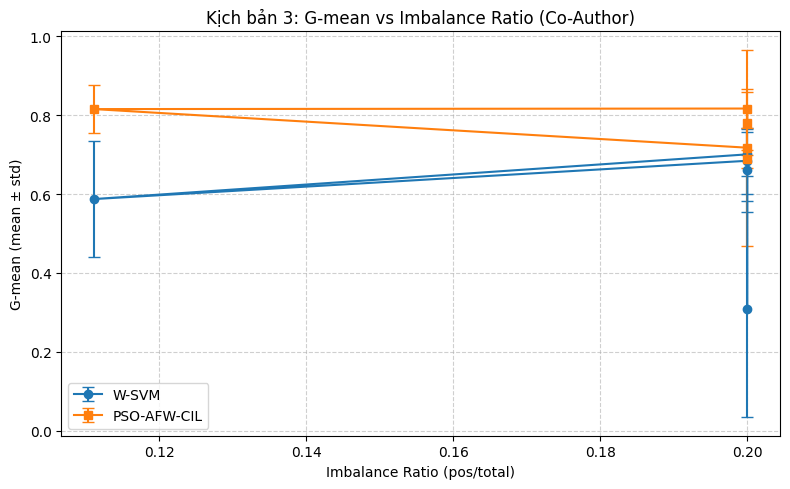

[✔] Plot: ./Experiment/Scenario3_CoAuthor_11032026_153220.png | CSV: ./Experiment/Scenario3_CoAuthor_11032026_153220.csv


In [ ]:
def run_scenario3(C=100, T=5,
                  namemethod="distance_center_own_opposite_tam",
                  namefunction="func_own_opp_new",
                  n_splits=5, n_repeats=10,
                  pso_particles=10, pso_iters=20,
                  bounds=None):
    """
    Kịch bản 3: Stress-test trên các biến thể Co-Author theo IR.
    Kết quả lưu vào: ./Experiment/Scenario3_CoAuthor_{ts}/
    Trả về DataFrame mean±std per IR và vẽ biểu đồ đường G-mean vs IR.
    """
    if bounds is None:
        bounds = [(3, 11), (0.01, 0.5), (0.01, 0.99), (0.01, 0.5), (0.01, 0.99)]

    coauthor_variants = [
        ("co_author_50_250",   "50/250",   50/250),
        ("co_author_100_500",  "100/500",  100/500),
        ("co_author_100_900",  "100/900",  100/900),
        ("co_author_200_1000", "200/1000", 200/1000),
        ("co_author_300_1500", "300/1500", 300/1500),
    ]
    available = []
    for ds_key, label, ir_val in coauthor_variants:
        cfg  = DATASET_CONFIG.get(ds_key, {})
        fpath = None
        for d in [_DS_PRIMARY, _DS_FALLBACK, '../data']:
            c = os.path.join(d, cfg.get("file", ""))
            if os.path.exists(c):
                fpath = c; break
        if fpath:
            available.append((ds_key, label, ir_val, fpath))
        else:
            print(f"[SKIP] {ds_key}: file '{cfg.get('file','')}' không tồn tại.")

    if not available:
        print("[!] Không có file Co-Author nào. Kiểm tra thư mục Processing_Data/dataset.")
        return None, None, None

    ts      = datetime.now().strftime("%d%m%Y_%H%M%S")
    run_dir = os.path.join(OUTPUT_DIR, f"Scenario3_CoAuthor_{ts}")
    os.makedirs(run_dir, exist_ok=True)
    csv_path = os.path.join(run_dir, f"Scenario3_CoAuthor_{ts}.csv")

    print(f"\n{'='*65}")
    print(f"Kịch bản 3 | {n_repeats}×{n_splits}-fold CV | Co-Author variants")
    print(f"Thư mục kết quả: {run_dir}")
    print(f"{'='*65}")

    summary_rows = []

    for ds_key, label, ir_val, fpath in available:
        print(f"\n[KB3] {ds_key}  IR≈{ir_val:.2f}  file={fpath}")

        cfg     = DATASET_CONFIG[ds_key]
        df_raw  = pd.read_csv(fpath)
        lbl_col = cfg["label_col"]
        df_raw[lbl_col] = df_raw[lbl_col].map(cfg["label_map"])
        df_raw = df_raw.dropna(subset=[lbl_col])
        y_all  = df_raw[lbl_col].values.astype(float)
        X_all  = df_raw.drop(columns=[lbl_col]).values.astype(float)

        wsvm_gm_list = []
        pso_gm_list  = []

        for rep in range(1, n_repeats + 1):
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep * 7)
            for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
                X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
                y_tr, y_te         = y_all[tr_idx], y_all[te_idx]

                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr_raw)
                X_te = sc.transform(X_te_raw)

                # W-SVM baseline
                pred_b = wsvm(C, X_tr, y_tr, X_te, np.ones(len(y_tr)))
                _, _, gm_b = Gmean(y_te, pred_b)
                wsvm_gm_list.append(gm_b)

                # PSO-AFW-CIL — reuse pso.ind_posX/negX/init_weight
                pso = PSO_AFWCIL(pso_particles, pso_iters, bounds, C, T,
                                  X_tr, y_tr, X_te, y_te, namemethod, namefunction)
                gbpos, _, _ = pso.optimize()
                K_b = int(round(float(gbpos[0])))
                best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight,
                                     T, X_te, y_te, X_tr, y_tr,
                                     K_b, gbpos[1], gbpos[2], gbpos[3], gbpos[4])
                pred_p = wsvm(C, X_tr, y_tr, X_te, best_w)
                _, _, gm_p = Gmean(y_te, pred_p)
                pso_gm_list.append(gm_p)

                # Ghi CSV
                for mname, pred_use in [("W-SVM", pred_b), ("PSO-AFW-CIL", pred_p)]:
                    sp, se, gm2 = Gmean(y_te, pred_use)
                    f1  = f1_score(y_te, pred_use, pos_label=1, zero_division=0)
                    acc = accuracy_score(y_te, pred_use)
                    auc = roc_auc_score(y_te, pred_use)
                    row = make_row(rep, fold, 0.0, mname, ds_key,
                                   sp, se, gm2, f1, acc, auc,
                                   str(confusion_matrix(y_te, pred_use, labels=[-1., 1.]).tolist()))
                    append_csv_row(csv_path, row)

            print(f"  [{ds_key}] Rep {rep:02d} ✓")

        # Checkpoint per dataset
        ckpt = os.path.join(run_dir, f"Scenario3_{ds_key}_ckpt.csv")
        if os.path.exists(csv_path):
            import shutil; shutil.copy(csv_path, ckpt)

        summary_rows.append({
            "Dataset":   label,
            "IR":        ir_val,
            "WSVM_mean": np.mean(wsvm_gm_list),
            "WSVM_std":  np.std(wsvm_gm_list),
            "PSO_mean":  np.mean(pso_gm_list),
            "PSO_std":   np.std(pso_gm_list),
        })

    df_summary = pd.DataFrame(summary_rows)
    sum_path = os.path.join(run_dir, f"Scenario3_CoAuthor_summary_{ts}.csv")
    df_summary.to_csv(sum_path, index=False)

    print("\n" + "="*65)
    print("BẢNG TỔNG KẾT KịCH BẢN 3 (G-mean mean±std)")
    print(df_summary.to_string(index=False))

    _, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(df_summary["IR"], df_summary["WSVM_mean"],
                yerr=df_summary["WSVM_std"], marker='o', label='W-SVM', capsize=4)
    ax.errorbar(df_summary["IR"], df_summary["PSO_mean"],
                yerr=df_summary["PSO_std"], marker='s', label='PSO-AFW-CIL', capsize=4)
    ax.set_xlabel("Imbalance Ratio (pos/total)")
    ax.set_ylabel("G-mean (mean ± std)")
    ax.set_title("Kịch bản 3: G-mean vs Imbalance Ratio (Co-Author)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plot_path = os.path.join(run_dir, f"Scenario3_CoAuthor_{ts}.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"[✔] Plot: {plot_path}")
    print(f"[✔] CSV:  {csv_path}")
    print(f"[✔] Thư mục: {run_dir}")

    return df_summary, csv_path, run_dir


# ============================================================
# CHẠY KịCH BẢN 3
# ============================================================
df3, csv3, run_dir3 = run_scenario3(C=100, T=5,
                                    n_splits=5, n_repeats=5,
                                    pso_particles=5, pso_iters=10)


---
## Kịch bản 4 — Ablation Study (chi phí tính toán: thời gian + bộ nhớ)

So sánh 4 cấu hình theo thời gian chạy và bộ nhớ đỉnh (tracemalloc):

| Config | K | Sigma | Particles | Iters |
|---|---|---|---|---|
| A | 6 | fixed 1.2 | — | T=5 |
| B | grid K∈[3,5,7] | grid σ∈[0.1,0.3] | — | T=5 |
| C | PSO | PSO | 5 | 10 |
| D | PSO | PSO | 10 | 20 |

In [ ]:
def run_scenario4(dataset_name, C=100, T=5,
                  namemethod="distance_center_own_opposite_tam",
                  namefunction="func_own_opp_new",
                  n_splits=5, n_repeats=3,
                  bounds=None):
    """
    Kịch bản 4: Ablation study — so sánh 4 cấu hình A/B/C/D
    theo G-mean, thời gian trung bình và bộ nhớ đỉnh (MB).
    Kết quả lưu vào: ./Experiment/{dataset_name}_ablation_{ts}/
    """
    from sklearn.model_selection import StratifiedKFold

    if bounds is None:
        bounds = [(3, 11), (0.01, 0.5), (0.01, 0.99), (0.01, 0.5), (0.01, 0.99)]

    ts      = datetime.now().strftime("%d%m%Y_%H%M%S")
    run_dir = os.path.join(OUTPUT_DIR, f"{dataset_name}_ablation_{ts}")
    os.makedirs(run_dir, exist_ok=True)
    csv_path  = os.path.join(run_dir, f"Scenario4_ablation_{dataset_name}_{ts}.csv")
    plot_path = os.path.join(run_dir, f"Scenario4_ablation_{dataset_name}_{ts}.png")

    # --- Load raw data ---
    cfg = DATASET_CONFIG[dataset_name]
    search_dirs = [_DS_PRIMARY, _DS_FALLBACK, '../data']
    fpath = None
    for d in search_dirs:
        c = os.path.join(d, cfg["file"])
        if os.path.exists(c):
            fpath = c; break
    if fpath is None:
        raise FileNotFoundError(cfg["file"])

    df = pd.read_csv(fpath)
    lbl_col = cfg["label_col"]
    df[lbl_col] = df[lbl_col].map(cfg["label_map"])
    df = df.dropna(subset=[lbl_col])
    y_all = df[lbl_col].values.astype(float)
    X_df  = df.drop(columns=[lbl_col] + cfg.get("drop_cols", []))
    if cfg["cat_cols"]:
        cat_idx = [X_df.columns.get_loc(c) for c in cfg["cat_cols"]]
        from sklearn.compose import ColumnTransformer
        from sklearn.preprocessing import OneHotEncoder
        ct = ColumnTransformer(
            [('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_idx)],
            remainder='passthrough')
        X_all = np.array(ct.fit_transform(X_df.values), dtype=float)
    else:
        X_all = X_df.values.astype(float)
    if cfg["impute"]:
        X_all = SimpleImputer(strategy='mean').fit_transform(X_all)

    print(f"\n{'='*65}")
    print(f"Kịch bản 4 | Dataset: {dataset_name} | {n_repeats}×{n_splits}-fold CV")
    print(f"Thư mục kết quả: {run_dir}")
    print(f"{'='*65}")

    configs = {
        "A_fixed":    {"type": "fixed",  "pso_particles": None, "pso_iters": None},
        "B_grid":     {"type": "grid",   "pso_particles": None, "pso_iters": None},
        "C_pso5x10":  {"type": "pso",    "pso_particles": 5,    "pso_iters": 10},
        "D_pso10x20": {"type": "pso",    "pso_particles": 10,   "pso_iters": 20},
    }

    results = {k: {"gm": [], "time_s": [], "mem_mb": []} for k in configs}

    for rep in range(1, n_repeats + 1):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep*7)
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
            X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
            y_tr, y_te         = y_all[tr_idx], y_all[te_idx]
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr_raw)
            X_te = sc.transform(X_te_raw)

            for cfg_name, cfg_params in configs.items():
                tracemalloc.start()
                t0 = time.time()

                if cfg_params["type"] == "fixed":
                    _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                    w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, namemethod, namefunction)
                    best_w, _, _ = lfb_fixed(C, posX, negX, w_init, T, X_te, y_te, X_tr, y_tr)
                    pred = wsvm(C, X_tr, y_tr, X_te, best_w)

                elif cfg_params["type"] == "grid":
                    # grid_search_afwcil tính posX/negX/init_weight một lần trong hàm
                    best_p, _, _ = grid_search_afwcil(
                        C, T, X_tr, y_tr, X_te, y_te, namemethod, namefunction,
                        K_grid=[3, 5, 7], sigma_grid=[0.1, 0.3])
                    _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                    w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, namemethod, namefunction)
                    s = best_p["sigma"]
                    best_w, _ = lfb_pso(C, posX, negX, w_init, T, X_te, y_te, X_tr, y_tr,
                                         best_p["K"], s, s, s, s)
                    pred = wsvm(C, X_tr, y_tr, X_te, best_w)

                else:  # pso — reuse pso.ind_posX/negX/init_weight
                    pso = PSO_AFWCIL(
                        cfg_params["pso_particles"], cfg_params["pso_iters"],
                        bounds, C, T, X_tr, y_tr, X_te, y_te, namemethod, namefunction)
                    gbpos, _, _ = pso.optimize()
                    K_b = int(round(float(gbpos[0])))
                    best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight,
                                         T, X_te, y_te, X_tr, y_tr,
                                         K_b, gbpos[1], gbpos[2], gbpos[3], gbpos[4])
                    pred = wsvm(C, X_tr, y_tr, X_te, best_w)

                elapsed = time.time() - t0
                _, peak_mem = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                peak_mb = peak_mem / 1024 / 1024

                sp, se, gm = Gmean(y_te, pred)
                f1  = f1_score(y_te, pred, pos_label=1, zero_division=0)
                acc = accuracy_score(y_te, pred)
                auc = roc_auc_score(y_te, pred)

                results[cfg_name]["gm"].append(gm)
                results[cfg_name]["time_s"].append(elapsed)
                results[cfg_name]["mem_mb"].append(peak_mb)

                row = make_row(rep, fold, round(elapsed, 4), cfg_name, cfg_params["type"],
                               sp, se, gm, f1, acc, auc,
                               str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist()))
                append_csv_row(csv_path, row)

        print(f"  Rep {rep:02d} ✓")

    # --- Bảng tổng kết Kịch bản 4 ---
    print(f"\n{'Config':<15} {'G-mean':>10} {'±':>4} {'Time(s)':>9} {'±':>4} {'Mem(MB)':>9} {'±':>4}")
    print("-"*65)
    ablation_rows = []
    for cfg_name in configs:
        gm_arr  = results[cfg_name]["gm"]
        t_arr   = results[cfg_name]["time_s"]
        m_arr   = results[cfg_name]["mem_mb"]
        print(f"{cfg_name:<15} {np.mean(gm_arr):>10.4f} {np.std(gm_arr):>6.4f}"
              f"  {np.mean(t_arr):>9.2f} {np.std(t_arr):>6.2f}"
              f"  {np.mean(m_arr):>9.2f} {np.std(m_arr):>6.2f}")
        ablation_rows.append({
            "Config":     cfg_name,
            "Gmean_mean": np.mean(gm_arr), "Gmean_std": np.std(gm_arr),
            "Time_mean":  np.mean(t_arr),  "Time_std":  np.std(t_arr),
            "Mem_mean":   np.mean(m_arr),  "Mem_std":   np.std(m_arr),
        })

    df_abl = pd.DataFrame(ablation_rows)
    sum_path = os.path.join(run_dir, f"Scenario4_ablation_{dataset_name}_summary_{ts}.csv")
    df_abl.to_csv(sum_path, index=False)

    # --- Bar chart ---
    _, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col_mean, col_std, ylabel in [
        (axes[0], "Gmean_mean", "Gmean_std", "G-mean"),
        (axes[1], "Time_mean",  "Time_std",  "Thời gian (s)"),
        (axes[2], "Mem_mean",   "Mem_std",   "Bộ nhớ đỉnh (MB)"),
    ]:
        ax.bar(df_abl["Config"], df_abl[col_mean],
               yerr=df_abl[col_std], capsize=5, alpha=0.8)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.tick_params(axis='x', rotation=25)

    plt.suptitle(f"Kịch bản 4 Ablation — {dataset_name}", fontsize=12)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"\n[✔] Kịch bản 4 hoàn thành.")
    print(f"  CSV:  {csv_path}")
    print(f"  Plot: {plot_path}")
    print(f"  Thư mục: {run_dir}")

    return df_abl, csv_path, run_dir


# ============================================================
# CHẠY KịCH BẢN 4  — TẠM THỜI VÔ HIỆU HOÁ (comment # để bỏ qua)
# Bỏ comment khi cần chạy ablation study
# ============================================================
# SCN4_DATASET = "haberman"   # << Thay tên dataset ở đây
#
# df4, csv4, run_dir4 = run_scenario4(SCN4_DATASET, C=100, T=5,
#                                     n_splits=5, n_repeats=3)


---
## Phân tích & Trực quan hoá Kết quả

Đọc CSV đã lưu → tính mean±std → vẽ biểu đồ so sánh tất cả các kịch bản.

In [ ]:
def compute_average_result(csv_path, metrics=None):
    """
    Đọc CSV kết quả và tính mean ± std theo 'Name Method'.
    Trả về DataFrame tổng hợp.
    """
    if metrics is None:
        metrics = ['SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC']

    df = pd.read_csv(csv_path)
    for m in metrics:
        df[m] = pd.to_numeric(df[m], errors='coerce')

    agg = {}
    for m in metrics:
        agg[f"{m}_mean"] = (m, 'mean')
        agg[f"{m}_std"]  = (m, 'std')

    summary = df.groupby("Name Method").agg(**agg).reset_index()
    return summary


def plot_comparison(summary_df, metric="Gmean",
                    title="So sánh phương pháp", save_dir=None):
    """
    Biểu đồ cột so sánh các phương pháp theo metric (mean ± std).
    Nếu save_dir được truyền, ảnh được lưu vào thư mục đó.
    """
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    _, ax = plt.subplots(figsize=(max(8, len(summary_df)*1.5), 5))
    colors = plt.colormaps['tab10'](np.linspace(0, 1, len(summary_df)))

    ax.bar(summary_df["Name Method"],
           summary_df[mean_col],
           yerr=summary_df[std_col],
           color=colors, alpha=0.85, capsize=5, edgecolor='black')
    ax.set_ylabel(f"{metric} (mean ± std)")
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname = title.replace(" ", "_").replace("|", "").replace("/", "-") + ".png"
        fpath = os.path.join(save_dir, fname)
        plt.savefig(fpath, dpi=150)
        print(f"[✔] Plot saved: {fpath}")
    plt.show()


# ================================================================
# Ví dụ sử dụng sau khi đã chạy các kịch bản
# Mỗi kịch bản bây giờ trả về (csv_path, ..., run_dir)
# → dùng run_dir tương ứng để lưu ảnh vào đúng thư mục kết quả
# (Bỏ comment dòng tương ứng với kịch bản đã chạy)
# ================================================================

# --- Kịch bản 1 ---
# if 'csv1' in dir():
#     s1 = compute_average_result(csv1)
#     print("\nKịch bản 1 — Tổng kết:")
#     display(s1)
#     plot_comparison(s1, metric="Gmean",
#                     title=f"KB1 | {SCN1_DATASET} | G-mean",
#                     save_dir=run_dir1)     # lưu vào thư mục run của KB1
#     plot_comparison(s1, metric="AUC",
#                     title=f"KB1 | {SCN1_DATASET} | AUC",
#                     save_dir=run_dir1)

# --- Kịch bản 2 ---
# if 'csv2' in dir():
#     s2 = compute_average_result(csv2)
#     print("\nKịch bản 2 — Tổng kết:")
#     display(s2)
#     plot_comparison(s2, metric="Gmean",
#                     title=f"KB2 | {SCN2_DATASET} | G-mean",
#                     save_dir=run_dir2)

# --- Kịch bản 3 (df3 đã có sẵn từ run_scenario3) ---
# if 'df3' is not None:
#     print("\nKịch bản 3 — Tổng kết:")
#     display(df3)

# --- Kịch bản 4 (df4 đã có sẵn từ run_scenario4) ---
# if 'df4' is not None:
#     print("\nKịch bản 4 — Tổng kết:")
#     display(df4)

# ----------------------------------------------------------------
# Gộp tất cả CSV từ nhiều kịch bản thành một bảng tổng hợp
# ----------------------------------------------------------------
def summarize_all_csvs(csv_list, labels=None, save_dir=None):
    """
    Gộp nhiều file CSV kết quả thành một bảng tổng hợp chung.
    csv_list : list of csv paths
    labels   : list of scenario labels (tùy chọn)
    save_dir : nếu không None, lưu bảng tổng hợp vào thư mục này
    """
    frames = []
    for i, cp in enumerate(csv_list):
        if not os.path.exists(cp):
            print(f"[SKIP] không tìm thấy: {cp}")
            continue
        df = pd.read_csv(cp)
        tag = labels[i] if labels and i < len(labels) else f"CSV_{i+1}"
        df["Scenario"] = tag
        frames.append(df)
    if not frames:
        print("[!] Không có CSV nào để tổng hợp.")
        return None
    combined = pd.concat(frames, ignore_index=True)
    for m in ['SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC']:
        combined[m] = pd.to_numeric(combined[m], errors='coerce')
    agg_dict = {}
    for m in ['Gmean', 'AUC', 'F1 Score']:
        agg_dict[f"{m}_mean"] = (m, 'mean')
        agg_dict[f"{m}_std"]  = (m, 'std')
    summary = combined.groupby(["Scenario", "Name Method"]).agg(**agg_dict).reset_index()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        out = os.path.join(save_dir, "AllScenarios_summary.csv")
        summary.to_csv(out, index=False)
        print(f"[✔] Bảng tổng hợp: {out}")
    return summary

# Ví dụ gọi sau khi tất cả kịch bản đã chạy:
# all_summary = summarize_all_csvs(
#     [csv1, csv2, csv3],
#     labels=["Scenario1", "Scenario2", "Scenario3"],
#     save_dir=OUTPUT_DIR,
# )
# display(all_summary)
